In [11]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.visualization_utils as visualization_utils
from constants.behavioral_constants import *
from constants.decoding_constants import *
from scripts.anova_analysis.stim_belief_unit_overlap import (
    OUTPUT_PATH, WHOLE_POP, STATISTICS, ALPHA,
)

plt.rcParams.update({"font.size": 16})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Single-unit stimulus / belief co-selectivity

The single-unit counterpart of `20260812_visualize_stim_belief_alignment.ipynb`, and the
measurement of `claude_notes/stim_belief_single_unit_anova_lite.md` part 4.

That population analysis reports `cos(v_stim, v_pref)`, which is an uncentered correlation of two
per-unit contrasts across units. Writing each unit's contribution as
`|d_s| |d_p| sign(d_s d_p)` shows two ways for it to vanish, and the cosine cannot tell them apart:

- **H1** — for almost every unit one magnitude is ~0, so the selective sets are disjoint
- **H3** — both magnitudes are large for many units but the sign is `+1` about half the time, so
  the two codes live in the same neurons and cancel in the population average

The cosine used the sign and nothing else. An ANOVA fraction of variance is a function of the
*squared* contrast, so it uses the magnitude and nothing else. These two plots are that magnitude
half, from two ANOVA runs sharing no trials:

```
Run S -- stimulus:  A (X not chosen) vs B1 (X chosen), both X-not-preferred
Run P -- belief:    B2 (X not preferred) vs C (X preferred), both X-chosen
```

An **item** is a (unit, feature, window) triple. Both statistics run on the exact per-item
permutation p-value rather than raw eta^2, because per-unit null levels are heterogeneous *and*
correlated between the two runs -- a noisy unit is noisy in both, so raw eta^2 would recover
firing-rate heterogeneity rather than co-selectivity.

- **rho** = co-selective items / what independence predicts from the observed marginals.
  1 means exactly independent, `> 1` co-selective, `< 1` anti-associated.
- **tau** = Spearman correlation of the two runs' p-values over every item. Threshold-free, so it
  uses all items rather than the few percent above alpha, and it is the more sensitive of the two
  when `N11` is small.

Feedback-locked windows only. `StimOnset` is written by the same script and every function
below takes the event as an argument, so it can be added back by passing `"StimOnset"`.

**Neither is read against zero.** The shuffle is the null: it carries whatever offset the
drift x belief-autocorrelation coupling leaves, which the disjoint trial pools do not touch. So
both plots show the true run against its own shuffle, which is the comparison that is the test.

In [12]:
# purple pair matching 20260812_visualize_stim_belief_alignment.ipynb -- this is that analysis's
# single-unit counterpart, so the true/shuffle series read the same way across the two notebooks
SERIES_ORDER = ["true", "shuffle"]
SERIES_TO_COLOR = {"true": "tab:purple", "shuffle": "#c5b0d5"}

# feedback-locked only. StimOnset is written by the same script and everything below takes the
# event as an argument, so adding it back is a matter of passing "StimOnset"
TRIAL_EVENT = "FeedbackOnsetLong"

# the pooled-subject rows are the headline; "SA" / "BL" are also written if you want to split
SUBJECT = "both"

# the overlap ratio is STORED as log rho -- the note reports it that way for symmetry -- and shown
# here as rho itself, so it reads directly as "x times what independence predicts"
STAT_TO_LABEL = {
    "log_rho": r"$\hat\rho$",
    "tau": r"$\hat\tau$",
}
STAT_TO_TITLE = {
    "log_rho": f"overlap ratio (alpha = {ALPHA})",
    "tau": "rank correlation of the two runs",
}
# where independence sits for each statistic. NOT the null -- the shuffle is
STAT_TO_REFERENCE = {"log_rho": 1.0, "tau": 0.0}

# significance bars mark the H3 direction: the statistic ABOVE its own shuffle, i.e. more
# co-selectivity than the null. "p_h1" is the mirrored test and is written alongside it, so
# swapping this constant draws bars for the disjoint-codes direction instead
SIG_DIRECTION = "p_h3"


def read_overlap(trial_event=TRIAL_EVENT, region=WHOLE_POP, subject=SUBJECT):
    """
    The true run's statistics, one row per (window, statistic).

    Written by scripts/anova_analysis/stim_belief_unit_overlap.py alongside the shuffle values and
    the per-item p-values, so a region or per-feature breakdown is a filter here rather than a re-run.
    """
    res = pd.read_pickle(os.path.join(OUTPUT_PATH, f"{trial_event}_overlap.pickle"))
    return res[(res.region == region) & (res.subject == subject)].copy()


def read_null(trial_event=TRIAL_EVENT, region=WHOLE_POP, subject=SUBJECT):
    """
    Every shuffle's statistics, one row per (window, statistic, shuffle_idx).

    Plotted rather than the summary's `null_mean` column so the band is a real spread over shuffles,
    the same way the population notebook plots its individual shuffle runs.
    """
    res = pd.read_pickle(os.path.join(OUTPUT_PATH, f"{trial_event}_null.pickle"))
    return res[(res.region == region) & (res.subject == subject)].copy()


def to_display_scale(values, statistic):
    """
    Stored scale -> plotted scale. exp() for the overlap ratio, identity for tau.

    Worth doing on the ratio scale rather than the log one for a reason beyond readability: a run
    with zero co-selective items has log rho = -inf, which no mean or SE can use, but rho = 0,
    which is an ordinary value. Shuffles hit that once N11 is down in the tens, so on the log scale
    they would have to be dropped from the band -- biasing it upward -- and here they are kept.
    """
    return np.exp(values) if statistic == "log_rho" else values


def series_for(statistic, trial_event=TRIAL_EVENT, region=WHOLE_POP, subject=SUBJECT):
    """
    True and shuffle stacked into one long frame, ready for a hue on `series`.
    """
    true = read_overlap(trial_event, region, subject)
    null = read_null(trial_event, region, subject)
    true = true[true.statistic == statistic][["WindowEndMilli", "value"]].assign(series="true")
    null = null[null.statistic == statistic][["WindowEndMilli", "value"]].assign(series="shuffle")

    res = pd.concat((true, null), ignore_index=True)
    res["value"] = to_display_scale(res.value.to_numpy(), statistic)
    # the middle of the 500 ms window, matching generate_frac_var_frac_sig_plots.py
    res["Time"] = res.WindowEndMilli / 1000 - 0.25
    res["trial_event"] = trial_event

    # nan means the statistic was undefined for that run -- one of the two marginals was empty, so
    # there was nothing to compute a ratio or a correlation over. Not the same as a zero
    n_nan = int(res.value.isna().sum())
    if n_nan:
        print(f"{trial_event}/{statistic}: {n_nan} of {len(res)} values undefined, dropped")
    return res

def pvals_for(statistic, trial_event=TRIAL_EVENT, region=WHOLE_POP, subject=SUBJECT,
              direction=SIG_DIRECTION):
    """
    Per-window p-values in the schema visualization_utils.plot_sig_bars consumes: Time and p.

    These are the permutation p-values the analysis script already wrote -- the statistic
    recomputed with each shuffle standing in as the true run, then counted. Nothing is tested here.

    Note the resolution floor. With 100 shuffles the smallest p expressible is 1/101 = 0.0099, so
    of visualization_utils.SIG_LEVELS only the p < 0.05 tier (thin) and, at the single most extreme
    ordering, p < 0.01 (medium) are reachable; the p < 0.001 tier (thick) never is. A thin bar here
    is the strongest tier the shuffle count supports, not a weak result.
    """
    res = read_overlap(trial_event, region, subject)
    res = res[res.statistic == statistic].copy()
    # same window-midpoint convention as the traces, so a bar sits under the point it belongs to.
    # plot_sig_bars draws each one back 100 ms from Time, which is the window step, so runs of
    # significant windows tile into one continuous bar
    res["Time"] = res.WindowEndMilli / 1000 - 0.25
    res["p"] = res[direction]
    return res[["Time", "p"]].sort_values("Time")

In [13]:
def plot_statistic(statistic, trial_event=TRIAL_EVENT, region=WHOLE_POP, subject=SUBJECT,
                   title=None):
    """
    True vs shuffle for one statistic, feedback-locked, with significance bars beneath.

    Styling follows scripts/figure_generation/generate_frac_var_frac_sig_plots.py: 500 ms windows
    placed at their midpoint, dotted markers at stimulus onset (-0.8 s) and feedback, and that
    script's feedback tick set. The figure is the width its feedback panel had there -- 33/53 of a
    9 inch two-panel figure -- so the traces keep the same density as the existing figures. The
    sig-bar strip is placed the way 20260812_visualize_stim_belief_alignment.ipynb places it.
    """
    res = series_for(statistic, trial_event, region, subject)

    fig, ax = plt.subplots(figsize=(6, 3))
    sns.lineplot(
        res, x="Time", y="value",
        hue="series", hue_order=SERIES_ORDER, palette=SERIES_TO_COLOR,
        linewidth=3, ax=ax, errorbar="sd"
    )

    # independence: rho = 1 is "exactly what the marginals predict", tau = 0 is no association.
    # This is NOT the null -- the shuffle is, and it carries whatever offset drift leaves
    ax.axhline(y=STAT_TO_REFERENCE[statistic], linestyle="dotted", color="black")
    ax.axvline(-.8, color="grey", linestyle="dotted", linewidth=3)
    ax.axvline(0, color="grey", linestyle="dotted", linewidth=3)

    # significance against this statistic's own shuffle, in a strip below the traces. Read the
    # limits BEFORE drawing, or the bars themselves rescale the axis they are positioned against
    bottom, top = ax.get_ylim()
    spacing = 0.08 * (top - bottom)
    visualization_utils.plot_sig_bars(
        pvals_for(statistic, trial_event, region, subject), bottom - spacing, ax,
        color=SERIES_TO_COLOR["true"]
    )
    # make room for the strip without rescaling the traces, and keep the ticks on the traces --
    # a tick inside the bar strip reads as data
    ax.set_ylim(bottom - 1.5 * spacing, top)
    ax.set_yticks([tick for tick in ax.get_yticks() if bottom <= tick <= top])

    ax.set_ylabel(STAT_TO_LABEL[statistic])
    ax.set_xlabel("Time to feedback (s)")
    fb_ticks = [-1.5, -1, -.5, 0, .5, 1, 1.5]
    ax.set_xticks(fb_ticks)
    ax.set_xticklabels(fb_ticks)

    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    for line in ax.get_legend().get_lines():
        line.set_linewidth(6)

    visualization_utils.format_plot(ax)
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    return fig, ax, res

## Overlap ratio

`rho = N11 * N / (N1. * N.1)` -- observed co-selectivity over what independence predicts *given the
observed marginals*, so it is invariant to the two runs having different power. 1 is independence.

H1 predicts below its shuffle, H3 above it. Check `N11` in the summary table below before reading
much into the trace: this statistic throws away every item below alpha, and with `N11` in the tens
the trace is noisy. The script stores this as `log rho`, which is why the `statistic` key is
`"log_rho"`; it is exponentiated for display.

The bar beneath the traces marks windows where this statistic is significantly **above** its own
shuffle (`p_h3`), which is the H3 direction.


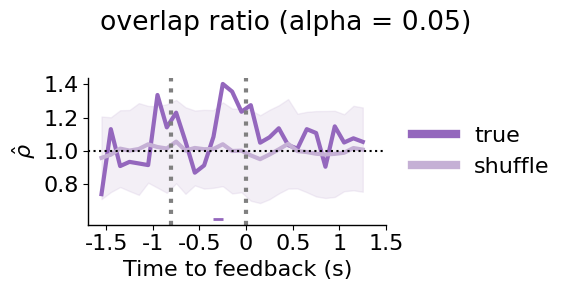

In [14]:
fig, ax, rho_res = plot_statistic("log_rho", title=STAT_TO_TITLE["log_rho"])

## Rank correlation

`tau = spearman(p_s, p_p)` over every item, no threshold. 0 under the null, positive under H3,
`<= 0` under H1. This is the one to read first.

The bar beneath the traces marks windows where this statistic is significantly **above** its own
shuffle (`p_h3`), which is the H3 direction.


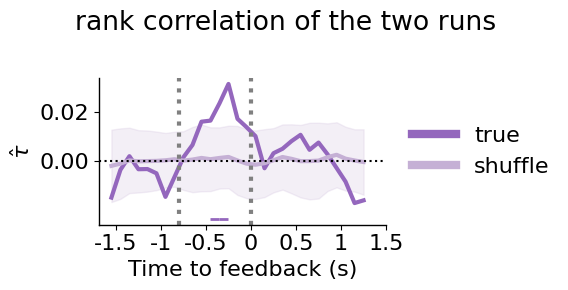

In [15]:
fig, ax, tau_res = plot_statistic("tau", title=STAT_TO_TITLE["tau"])

## The numbers behind the traces

`p_h3` / `p_h1` are the one-sided permutation p-values against the shuffles in each direction, and
`N11 / N1_ / N_1 / N` are the contingency counts. Two things worth checking here rather than in the
plot:

- **Marginals.** `N1_ / N` and `N_1 / N` are the two runs' selection rates. Both floor at `alpha`
  by construction, so the excess over `alpha` is how much real selectivity each run detects. If a
  run barely clears the floor, neither statistic has the power to separate H1 from H3.
- **Window overlap.** 500 ms windows stepped by 100 ms share 80% of their data, so adjacent
  windows are not independent tests -- there are only ~6-7 independent windows per event.

In [22]:
cols = ["WindowStartMilli", "value", "null_mean", "p_h3", "p_h1", "N11", "N1_", "N_1", "N"]
res = read_overlap()
res["rate_stim"] = res.N1_ / res.N
res["rate_belief"] = res.N_1 / res.N
for statistic in STATISTICS:
    sub = res[res.statistic == statistic].sort_values("WindowStartMilli").copy()
    # the overlap ratio is stored as log rho; show it on the plotted scale. exp of the mean log is
    # the GEOMETRIC mean of the shuffles' rho, which is the right centre for a ratio -- so it will
    # not exactly equal the arithmetic mean the plotted band draws
    sub[["value", "null_mean"]] = to_display_scale(sub[["value", "null_mean"]].to_numpy(), statistic)
    print(f"\n--- {TRIAL_EVENT}, whole population: "
          f"{'rho' if statistic == 'log_rho' else statistic} ---")
    print(sub[cols].to_string(index=False))
print(f"\nselection rate vs the alpha={ALPHA} floor: "
      f"stimulus {res.rate_stim.min():.3f}-{res.rate_stim.max():.3f}, "
      f"belief {res.rate_belief.min():.3f}-{res.rate_belief.max():.3f}")


--- FeedbackOnsetLong, whole population: rho ---
 WindowStartMilli    value  null_mean     p_h3     p_h1  N11  N1_  N_1    N
            -1800 0.741282   0.922078 0.841584 0.168317   14  338  329 5888
            -1700 1.130531   0.951207 0.257426 0.752475   21  339  324 5913
            -1600 0.909420   0.986755 0.633663 0.376238   17  346  320 5923
            -1500 0.934534   0.973059 0.584158 0.425743   17  342  316 5941
            -1400 0.925086   0.971862 0.633663 0.376238   17  325  337 5960
            -1300 0.915290   1.014967 0.643564 0.366337   17  320  345 5944
            -1200 1.335029   0.994305 0.128713 0.881188   27  358  335 5930
            -1100 1.141139   0.978440 0.297030 0.712871   29  447  336 5910
            -1000 1.229153   1.025522 0.247525 0.762376   37  517  343 5891
             -900 1.057260   0.970179 0.336634 0.673267   34  543  348 5876
             -800 0.869760   0.992256 0.762376 0.247525   30  592  343 5887
             -700 0.913522   0.979270 